# Purchasing Power Parity (PPP) — Interactive Exercise
## International Money and Finance | Prof. Dr. Eric Mayer

---

This notebook explores **Purchasing Power Parity (PPP)** — one of the 
fundamental theories linking exchange rates to price levels across countries.

### What you will do in this notebook:

1. **Interactive PPP Explorer** — Experiment with inflation differentials 
   and see how the exchange rate should change according to relative PPP
2. **Price Level Developments** — Compare US and German price levels 
   since 1999
3. **Actual vs. PPP-Implied Exchange Rate** — How well does PPP explain 
   the EUR/USD exchange rate since 1999?
4. **Statistical PPP Test** — OLS regression and Engle-Granger 
   Error Correction Model (ECM)

---
> **Data sources:** FRED (Federal Reserve Bank of St. Louis)  
> US CPI: CPIAUCSL | German HICP: CP0000DEM086NEST | 
> Exchange Rate: DEXUSEU  
> Base year for price indices: **2015 = 100**

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from ipywidgets import interact, FloatSlider, VBox, HBox, Label, HTML
import ipywidgets as widgets

from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS

# Plot styling
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


# ── Load raw data ─────────────────────────────────────────────────────────────
url_base = ("https://raw.githubusercontent.com/"
            "mayeric97070/PPP-Exercise-Notebook-for-"
            "International-Money-and-Finance/main/")

cpi_us_raw = pd.read_csv(url_base + "CPIAUCSL.csv")
cpi_de_raw = pd.read_csv(url_base + "CP0000DEM086NEST.csv")
fx_raw     = pd.read_csv(url_base + "DEXUSEU.csv")

# Convert date column to datetime and set as index
cpi_us_raw['observation_date'] = pd.to_datetime(cpi_us_raw['observation_date'])
cpi_de_raw['observation_date'] = pd.to_datetime(cpi_de_raw['observation_date'])
fx_raw['observation_date']     = pd.to_datetime(fx_raw['observation_date'])

cpi_us_raw = cpi_us_raw.set_index('observation_date')
cpi_de_raw = cpi_de_raw.set_index('observation_date')
fx_raw     = fx_raw.set_index('observation_date')

# Rename columns for clarity
cpi_us_raw.columns = ['CPI_US_raw']
cpi_de_raw.columns = ['CPI_DE_raw']
fx_raw.columns     = ['EURUSD']

# ── Filter: 1999-01-01 onwards ────────────────────────────────────────────────
start = '1999-01-01'
cpi_us_raw = cpi_us_raw.loc[start:]
cpi_de_raw = cpi_de_raw.loc[start:]
fx_raw     = fx_raw.loc[start:]

# ── Replace '.' (missing) with NaN and drop ───────────────────────────────────
fx_raw = fx_raw.replace('.', np.nan).dropna()
fx_raw['EURUSD'] = fx_raw['EURUSD'].astype(float)

# ── Resample FX to monthly (mean of daily values) ────────────────────────────
fx_monthly = fx_raw.resample('MS').mean()

# ── Rebase both CPIs to 2015 = 100 ───────────────────────────────────────────
def rebase(series, base_year=2015):
    """Rebase an index series so that the average of base_year = 100."""
    base_val = series.loc[str(base_year)].mean()
    return (series / base_val) * 100

cpi_us = rebase(cpi_us_raw['CPI_US_raw']).rename('CPI_US')
cpi_de = rebase(cpi_de_raw['CPI_DE_raw']).rename('CPI_DE')

# ── Merge into one DataFrame ──────────────────────────────────────────────────
df = pd.concat([cpi_us, cpi_de, fx_monthly], axis=1).dropna()
df.index.name = 'Date'

print(f"✅ Data loaded. Shape: {df.shape}")
print(f"   Date range : {df.index[0].date()} → {df.index[-1].date()}")
print(f"\nFirst rows:")
df.head(3)

---
## Part 1: Interactive PPP Explorer

According to **Relative PPP**, the percentage change in the nominal 
exchange rate equals the inflation differential between two countries:

$$\frac{\Delta E_{\$/€,t}}{E_{\$/€,t}} = \pi_{US,t} - \pi_{EUR,t}$$

**How to use this explorer:**
- Use the sliders to set annual inflation rates for the US and the Euro Area
- The chart shows how the EUR/USD exchange rate *should* evolve over 
  10 years according to relative PPP
- Start from the current approximate rate of **1.08 USD/EUR**

---
## Part 2: Price Level Developments — USA vs. Germany (1999–today)

Both price indices are rebased to **2015 = 100**.  
The gap between the two lines represents the cumulative inflation 
differential — the key driver of exchange rate changes under PPP.

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df['CPI_US'], lw=2, color='steelblue',
        label='USA — CPI (CPIAUCSL)')
ax.plot(df.index, df['CPI_DE'], lw=2, color='darkorange',
        label='Germany — HICP (CP0000DEM086NEST)')
ax.axhline(100, color='grey', lw=1, ls='--',
           alpha=0.6, label='Base year 2015 = 100')

# Shade the gap
ax.fill_between(df.index, df['CPI_US'], df['CPI_DE'],
                where=df['CPI_US'] >= df['CPI_DE'],
                alpha=0.12, color='steelblue',
                label='US prices relatively higher')
ax.fill_between(df.index, df['CPI_US'], df['CPI_DE'],
                where=df['CPI_US'] < df['CPI_DE'],
                alpha=0.12, color='darkorange',
                label='German prices relatively higher')

ax.set_title('Price Level Developments: USA vs. Germany (1999–today)\n'
             'Both indices rebased to 2015 = 100',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price Index (2015 = 100)')
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=9)

# Annotate latest values
for col, color, label in [('CPI_US', 'steelblue', 'USA'),
                           ('CPI_DE', 'darkorange', 'Germany')]:
    last_val  = df[col].iloc[-1]
    last_date = df.index[-1]
    ax.annotate(f'{label}: {last_val:.1f}',
                xy=(last_date, last_val),
                xytext=(-60, 10), textcoords='offset points',
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1))

plt.tight_layout()
plt.show()

# Summary statistics
print("\n── Cumulative Inflation Summary ──────────────────────────")
cum_us = (df['CPI_US'].iloc[-1] / df['CPI_US'].iloc[0] - 1) * 100
cum_de = (df['CPI_DE'].iloc[-1] / df['CPI_DE'].iloc[0] - 1) * 100
print(f"  USA cumulative inflation since Jan 1999:     {cum_us:.1f}%")
print(f"  Germany cumulative inflation since Jan 1999: {cum_de:.1f}%")
print(f"  Differential (US − DE):                      {cum_us - cum_de:+.1f}%")

---
## Part 3: Actual vs. PPP-Implied Exchange Rate (1999–today)

Under **absolute PPP**, the nominal exchange rate should equal the 
ratio of price levels:

$$E_{\$/€} = \frac{P_{US}}{P_{DE}}$$

We anchor this to the **actual exchange rate in January 1999** 
(the start of the Euro) and then let the PPP-implied rate evolve 
according to cumulative price level changes.

This is equivalent to asking:  
*"If relative PPP had held perfectly since 1999, where would the 
exchange rate be today?"*

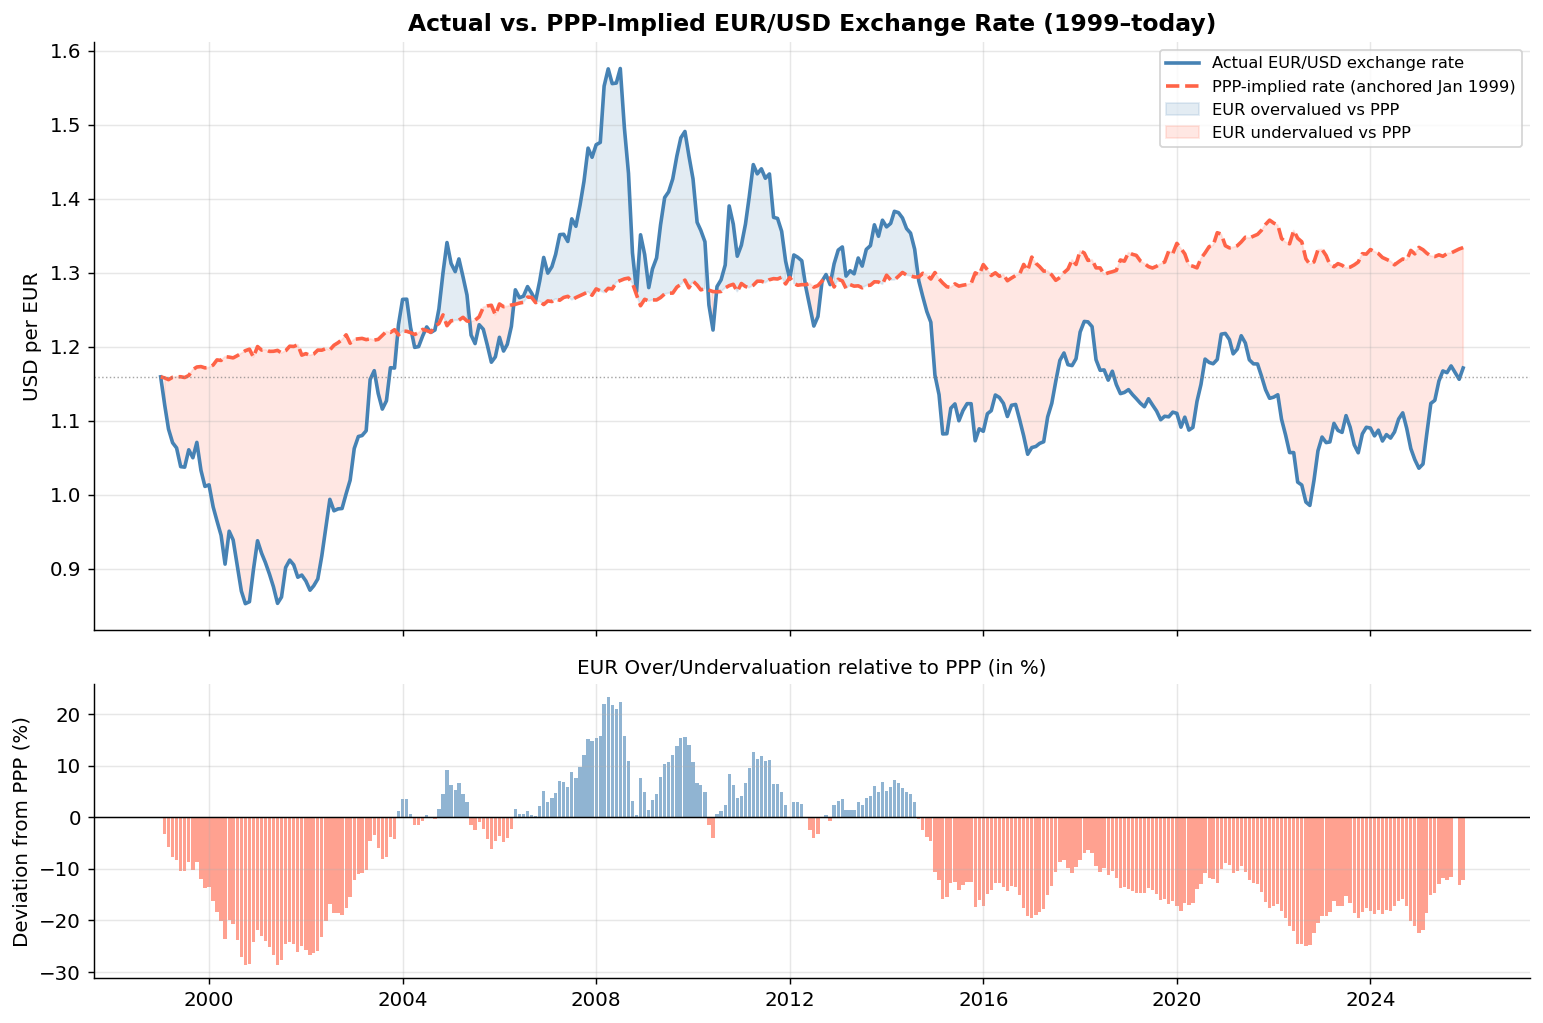


── Latest Observation (2025-12-01) ─────────────
  Actual exchange rate:      1.1710 USD/EUR
  PPP-implied rate:          1.3338 USD/EUR
  Misalignment:              -12.2% → EUR is undervalued vs PPP


In [10]:
# ── Compute PPP-implied exchange rate ─────────────────────────────────────────
E_anchor  = df['EURUSD'].iloc[0]
P_US_base = df['CPI_US'].iloc[0]
P_DE_base = df['CPI_DE'].iloc[0]

df['PPP_implied'] = (E_anchor * 
                    (df['CPI_US'] / P_US_base) / 
                    (df['CPI_DE'] / P_DE_base))

df['Misalignment'] = (df['EURUSD'] / df['PPP_implied'] - 1) * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8),
                                gridspec_kw={'height_ratios': [2, 1]},
                                sharex=True)

# Upper panel
ax1.plot(df.index, df['EURUSD'], lw=2, color='steelblue',
         label='Actual EUR/USD exchange rate')
ax1.plot(df.index, df['PPP_implied'], lw=2, color='tomato', ls='--',
         label='PPP-implied rate (anchored Jan 1999)')
ax1.fill_between(df.index, df['EURUSD'], df['PPP_implied'],
                 where=df['EURUSD'] >= df['PPP_implied'],
                 alpha=0.15, color='steelblue',
                 label='EUR overvalued vs PPP')
ax1.fill_between(df.index, df['EURUSD'], df['PPP_implied'],
                 where=df['EURUSD'] < df['PPP_implied'],
                 alpha=0.15, color='tomato',
                 label='EUR undervalued vs PPP')
ax1.set_ylabel('USD per EUR')
ax1.set_title('Actual vs. PPP-Implied EUR/USD Exchange Rate (1999–today)',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.axhline(E_anchor, color='grey', lw=0.8, ls=':', alpha=0.7)

# Lower panel
ax2.bar(df.index, df['Misalignment'],
        color=np.where(df['Misalignment'] >= 0, 'steelblue', 'tomato'),
        alpha=0.6, width=25,
        label='% deviation from PPP')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Deviation from PPP (%)')
ax2.set_title('EUR Over/Undervaluation relative to PPP (in %)',
              fontsize=11)

plt.tight_layout()
plt.show()

# Summary
last_mis  = df['Misalignment'].iloc[-1]
direction = "overvalued" if last_mis > 0 else "undervalued"
print(f"\n── Latest Observation ({df.index[-1].date()}) ─────────────")
print(f"  Actual exchange rate:      {df['EURUSD'].iloc[-1]:.4f} USD/EUR")
print(f"  PPP-implied rate:          {df['PPP_implied'].iloc[-1]:.4f} USD/EUR")
print(f"  Misalignment:              {last_mis:+.1f}% → EUR is {direction} vs PPP")